In [14]:
from deep_kolmogorov import modeling, pdes, trainer
import torch

# model = modeling.KolmogorovNet(modeling.DeepONet(1,{"size_t_s_u": [1,1,3], "num_depth" : 6, "num_width" : 55}), pdes.BSr())
# path = "./exp/avg_bs_r_2023_10_02_00_58_02/Trainer_2023-10-02_00-58-02/Trainer_aed00_00005_5_num_depth=6,num_width=55,seed=0_2023-10-02_00-58-02/checkpoint_000030"
# model.net.load_state_dict(torch.load(f"{path}/model.pth", map_location=torch.device('cuda')))

In [15]:
def get_option_price_curve(model, K, num_path, config):
    device = torch.device("cuda")
    with torch.no_grad(): 
        data = {
            key: torch.full(((K+1)*num_path, 1), value, dtype=torch.float32, device=device) for key, value in config.items()
        }
        data.update(
            {
                "t": torch.linspace(model.pde.hypercubes["t"].interval[0], model.pde.hypercubes["t"].interval[1], K + 1, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
            }
        )
        batch = {
            key: torch.full((num_path, 1), value, dtype=torch.float32, device=device) for key, value in config.items()
        }
        x = torch.full((num_path,K+1), 1, dtype=torch.float32, device=device)
        for i in range(K+1):
            x[:,i] = batch["s"].squeeze(1).clone()
            dw = (1/K)** 0.5  * torch.randn(
                batch["s"].shape, dtype=batch["s"].dtype, device=batch["s"].device
            )
            batch["s"] = batch["s"] * torch.exp(
                batch["r"] * 1/K - 0.5 * 1/K * batch["sigma"] ** 2 + batch["sigma"] * dw
            )
        if type(model.pde).__name__ == "BSr":
            data["x"] = x.reshape(-1,1)
        elif type(model.pde).__name__ == "BSlookback":
            mt = torch.concat([torch.min(x[:,:_i], dim=1).values.reshape(-1,1) for _i in range(1,K+2)], dim=1)
            data["x"] = torch.concat([x.reshape(-1,1), mt.reshape(-1,1)], dim=1)
        
        if model.pde.get_K is not None:
            data["K"] = model.pde.get_K(data)
        tensor = model.pde.normalize_and_flatten(data)
        y_pred = model.net.forward(tensor)
        y_true = model.pde.solution(data)
    return {
        "t": data["t"].reshape(num_path, K+1),
        "y_pred": y_pred.reshape(num_path, K+1),
        "y_true": y_true.reshape(num_path, K+1)
        }


In [3]:
import matplotlib.pyplot as plt

def plot_mc_curves(t_test, y_pred, y_true=None):
    if t_test.device != "cpu":
        t_test= t_test.cpu()
    if y_pred.device != "cpu":
        y_pred= y_pred.cpu()
    if y_true.device != "cpu":
        y_true= y_true.cpu()
    samples = 16
    plt.figure(figsize=(13, 8))
    plt.plot(t_test[0:1,:].T, y_pred[0:1,:].T,'darkviolet',label='Learned solution')
    plt.plot(t_test[0:1,:].T, y_true[0:1,:].T,'--',color='lightseagreen',label='Exact solution')
    # plt.plot(t_test[0:1,-1], y_true[0:1,-1],'ko')

    plt.plot(t_test[1:samples,:].T, y_pred[1:samples,:].T,'darkviolet')
    plt.plot(t_test[1:samples,:].T, y_true[1:samples,:].T,'--',color='lightseagreen')
    # plt.plot(t_test[1:samples,-1], y_true[1:samples,-1],'ko')

    # plt.plot([0],y_true[0,0],'ks') # ,label='$Y_0 = u(0,X_0)$')

    plt.xlabel('time', fontdict={"size": 18})
    plt.ylabel('price', fontdict={"size": 18})
    #plt.title(fr'm={u_hat[-1]: 2f}, r={u_hat[0]: 2f}, $\theta$={u_hat[1]: 2f},$\kappa$={u_hat[2]: 2f}， $\sigma$={u_hat[3]: 2f}, $\rho$={u_hat[4]: 2f}')# , $\rho$={u_hat[2]: 2f}')
    plt.legend(prop={"size": 15})
    plt.show()

# res = get_option_price_curve(model, 100, 2, {"s":9.5, "r":0.03, "sigma": 0.3, "kappa":1.05})
# plot_mc_curves(res["t"], res["y_pred"], res["y_true"])


In [30]:
config={
  "bs": 131072,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_r",
  "n_iterations": 30,
  "n_test_batches": 150,
  "n_train_batches": 2000,
  "net": "DeepONet",
  "norm_layer": "layernorm",
  "num_depth": 5,
  "num_width": 55,
  "opt": "adamw",
  "pde": "BSr",
  "seed": 0,
  "size_t_x_u": [
    1,
    1,
    3
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_r_2023_10_02_22_19_14/Trainer_2023-10-02_22-19-14/Trainer_a9e2f_00001_1_num_depth=5,num_width=55,seed=0_2023-10-02_22-19-14/checkpoint_000030/model.pth"
mytrainer.load_checkpoint(path)


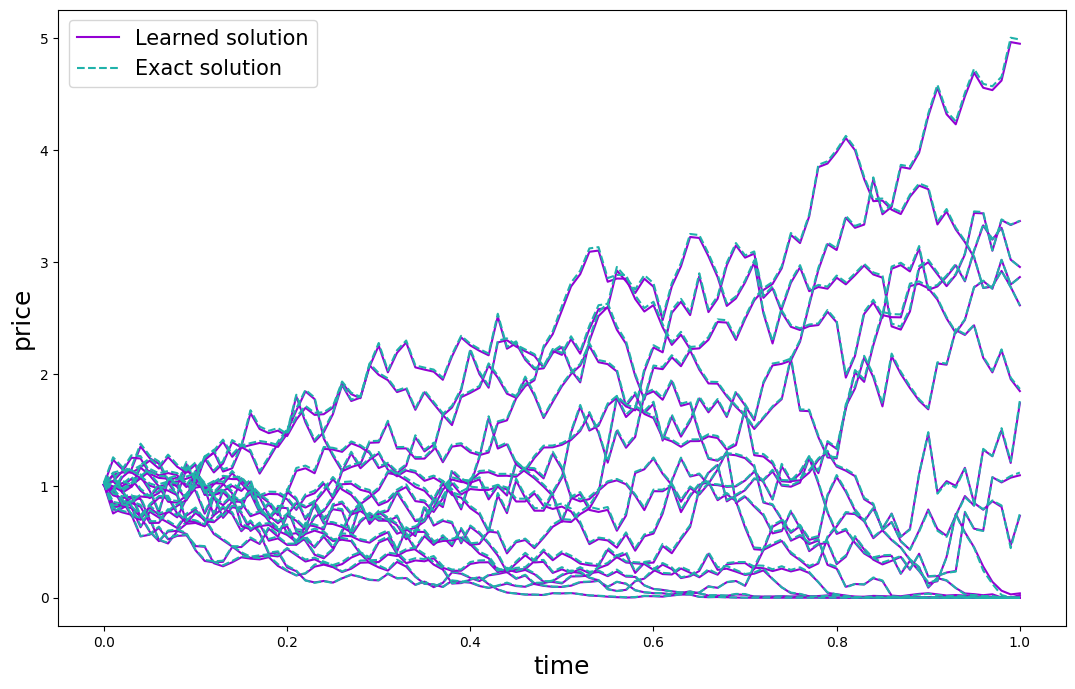

In [35]:
config = {"s":9.5, "r":0.03, "sigma": 0.3, "kappa":1.01}
res = get_option_price_curve(mytrainer.model.module, 100, 16,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])

In [22]:
import importlib
importlib.reload(trainer)
pde = pdes.BSasian()

In [29]:
# dtl = pde.dataloader(120000,2000,"train")

# for batch in dtl:
#     pass


In [27]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_lookback",
  "n_iterations": 30,
  "n_test_batches": 150,
  "n_train_batches": 2000,
  "net": "DeepONet",
  "norm_layer": "layernorm",
  "num_depth": 5,
  "num_width": 55,
  "opt": "adamw",
  "pde": "BSlookback",
  "seed": 0,
  "size_t_x_u": [
    1,
    2,
    2
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}
mytrainer = trainer.Trainer(config)
path = "./exp/avg_bs_lookback_2023_10_12_21_42_09/Trainer_2023-10-12_21-42-09/Trainer_23f55_00001_1_num_width=55,seed=0_2023-10-12_21-42-09/checkpoint_000030/model.pth"
mytrainer.load_checkpoint(path)


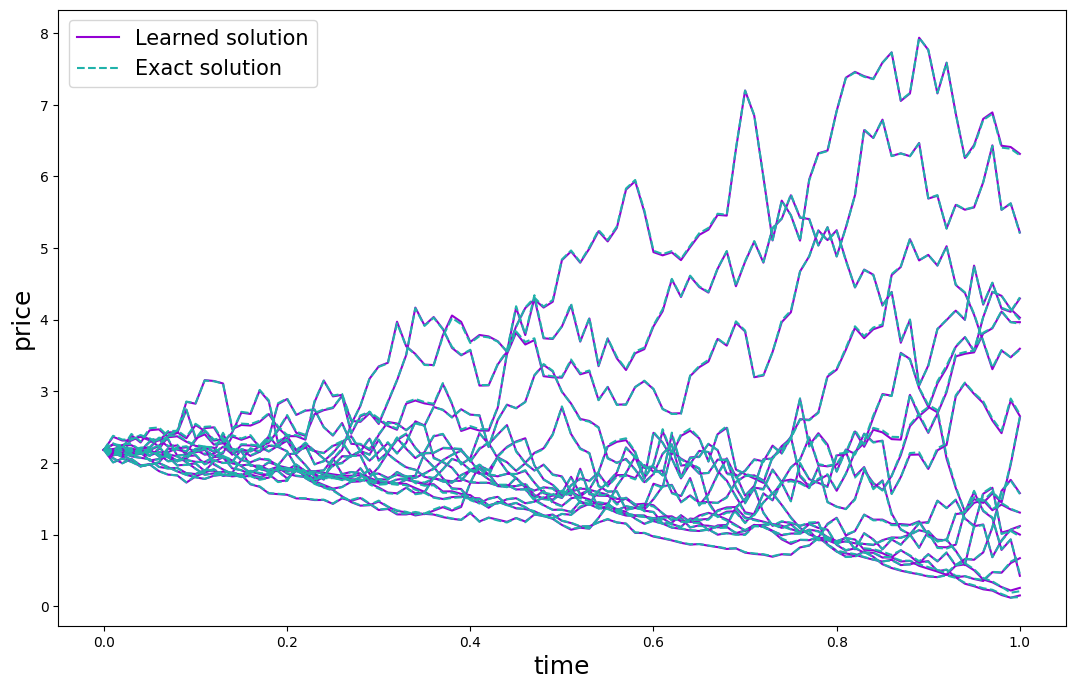

In [28]:
# config = {"s":10, "r":0.03, "sigma": 0.3, "kappa":1.01}
config = {"s":9.5, "r":0.03, "sigma": 0.3}
res = get_option_price_curve(mytrainer.model.module, 100, 16,config)
#  for data in datas: 
plot_mc_curves(res["t"], res["y_pred"], res["y_true"])

In [18]:
import importlib
importlib.reload(trainer)
pde = pdes.BSasian()
import numpy as np
K = 100
num_path = 10000
device = torch.device("cuda")
config = {"s":10, "r":0.02, "sigma": 0.3, "kappa": 1.01}

import importlib
importlib.reload(pdes)
pde = pdes.BSasian()

with torch.no_grad(): 
    data = {
        key: torch.full(((K+1)*num_path, 1), value, dtype=torch.float32, device=device) for key, value in config.items()
    }
    data.update(
        {
            "t": torch.linspace(0, 1, K + 1, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
        }
    )

data["x"] = pdes.BSasian.get_X(data)
data["K"] = pdes.BSasian.get_K(data)
payoff = pde.sde(data)

C0 = torch.mean(payoff)
cstd = torch.std(payoff)
print("Estimated price: ", C0)
print("Estimated CI: ", f"[{C0 - 1.96*cstd/np.sqrt(K*num_path)}, {C0 + 1.96*cstd/np.sqrt(K*num_path)}]")

print("exact price: ", pde.solution(data)[0,0])

Estimated price:  tensor(0.6463, device='cuda:0')
Estimated CI:  [0.6441922783851624, 0.6484270691871643]
exact price:  tensor(0.6436, device='cuda:0')


In [48]:
import importlib
importlib.reload(trainer)
pde = pdes.BSasian()
import numpy as np
K = 100
num_path = 10000
device = torch.device("cuda")
config = {"s":10, "r":0.02, "sigma": 0.3, "kappa": 1.01}

import importlib
importlib.reload(pdes)
pde = pdes.BSasian()

with torch.no_grad(): 
    data = {
        key: torch.full(((K+1)*num_path, 1), value, dtype=torch.float32, device=device) for key, value in config.items()
    }
    data.update(
        {
            "t": torch.full((K + 1,), 0.7, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
        }
    )

data["x"] = torch.concat([data["s"]+1, data["s"]], dim=1)
data["K"] = pdes.BSasian.get_K(data)
payoff = pde.sde(data)

C0 = torch.mean(payoff)
cstd = torch.std(payoff)
print("Estimated price: ", C0)
print("Estimated CI: ", f"[{C0 - 1.96*cstd/np.sqrt(K*num_path)}, {C0 + 1.96*cstd/np.sqrt(K*num_path)}]")

print("exact price: ", pde.solution(data)[0,0])


Estimated price:  tensor(0.2251, device='cuda:0')
Estimated CI:  [0.22469006478786469, 0.22557972371578217]
exact price:  tensor(0.2107, device='cuda:0')


In [53]:
import importlib
importlib.reload(trainer)
pde = pdes.BSbasket()
import numpy as np
K = 100
num_path = 10000
device = torch.device("cuda")
d = 2
config = {"s":10, "r":0.02, "sigma": 0.3, "rho": 0.1, "kappa": 1.01}

with torch.no_grad(): 
    data = {
        key: torch.full(((K+1)*num_path, pde.hypercubes[key].dims[0]), value, dtype=torch.float32, device=device) for key, value in config.items()
    }
    data.update(
        {
            "t": torch.linspace(0, 1, K + 1, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
            # "t": torch.full((K + 1,), 0.7, dtype=torch.float32, device=device).repeat(num_path).reshape(-1,1)
        }
    )

data["x"] = pdes.BSbasket.get_X(data)
data["K"] = pdes.BSbasket.get_K(data)
payoff = pde.sde(data)

C0 = torch.mean(payoff)
cstd = torch.std(payoff)
print("Estimated price: ", C0)
print("Estimated CI: ", f"[{C0 - 1.96*cstd/np.sqrt(K*num_path)}, {C0 + 1.96*cstd/np.sqrt(K*num_path)}]")

print("exact price: ", pde.solution(data)[0,0])


Estimated price:  tensor(0.8241, device='cuda:0')
Estimated CI:  [0.8213368058204651, 0.826904833316803]
exact price:  tensor(0.8231, device='cuda:0')


In [12]:
import importlib
importlib.reload(trainer)

<module 'deep_kolmogorov.trainer' from '/home/ycui/Documents/my_deepkol/deep_kolmogorov/trainer.py'>

In [13]:
config = {
  "bs": 120000,
  "checkpoint": True,
  "factor": 6,
  "gpus": 1,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_basket_PI",
  "n_iterations": 30,
  "n_test_batches": 1,
  "n_train_batches": 2000,
  "net": "DeepONetwithPI",
  "norm_layer": "layernorm",
  "num_assets": 10,
  "num_depth": 5,
  "num_width": 75,
  "opt": "adamw",
  "pde": "BSbasket",
  "pi_layer": [
    100,
    100
  ],
  "seed": 0,
  "size_t_x_u": [
    1,
    50,
    13
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "weight_decay": 0.01
}

mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/my_deepkol/exp/avg_bs_basket_PI_2023_10_18_01_01_45/Trainer_2023-10-18_01-01-45/Trainer_da9e6_00005_5_num_depth=5,num_width=75,pi_layer=100_100,seed=0_2023-10-18_01-01-46/checkpoint_000030/model.pth"
mytrainer.load_checkpoint(path)

/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

RuntimeError: Error(s) in loading state_dict for DeepONetwithPI:
	Unexpected key(s) in state_dict: "PI_layers.0.kernel", "PI_layers.0.bias", "PI_layers.1.kernel", "PI_layers.1.bias". 